In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.datasets import make_blobs

In [4]:
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns

In [2]:
X_ham, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)
df = pd.DataFrame(X_ham, columns=['Yenilik (Recency)', 'Harcama (Monetary)'])

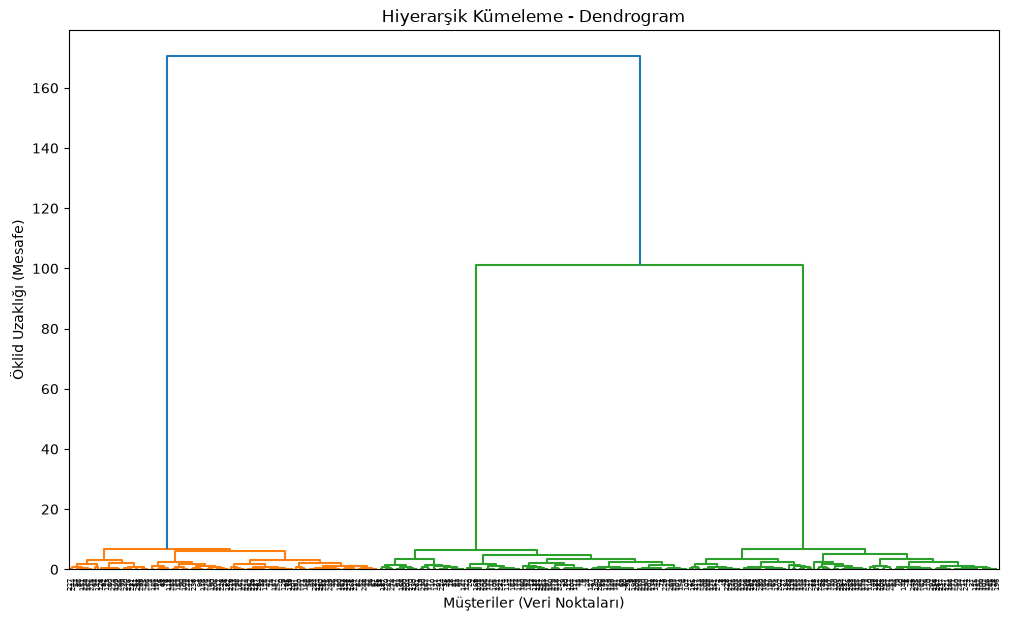

In [3]:
# Dendrogram
plt.figure(figsize=(12, 7))
plt.title("Hiyerarşik Kümeleme - Dendrogram")
plt.xlabel("Müşteriler (Veri Noktaları)")
plt.ylabel("Öklid Uzaklığı (Mesafe)")

# 'ward' metodu, kümeler arası varyansı (farklılığı) minimize eden en popüler birleştirme tekniğidir
dendrogram = sch.dendrogram(sch.linkage(df, method='ward'))

plt.show()

In [5]:
hc_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

df['Segment_HC'] = hc_model.fit_predict(df[['Yenilik (Recency)', 'Harcama (Monetary)']])

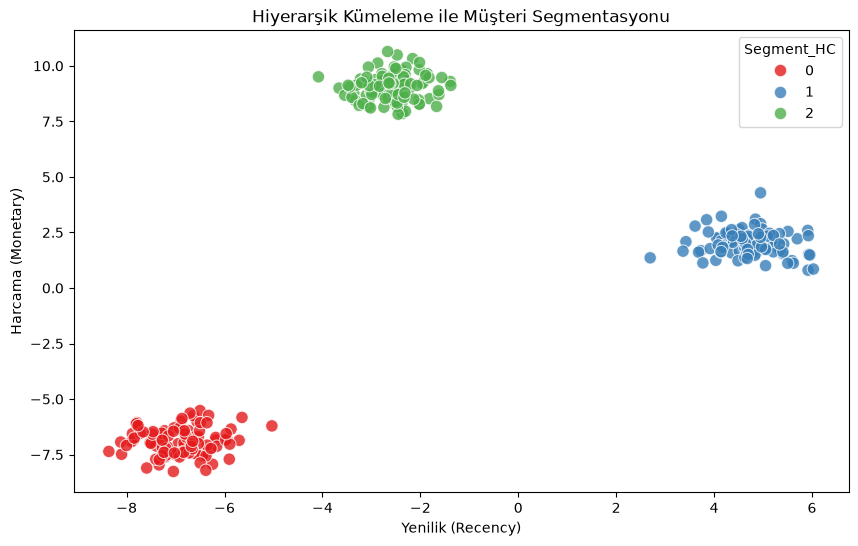

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Yenilik (Recency)', 
    y='Harcama (Monetary)', 
    hue='Segment_HC', 
    data=df, 
    palette='Set1', 
    s=80, 
    alpha=0.8
)
plt.title('Hiyerarşik Kümeleme ile Müşteri Segmentasyonu')
plt.show()